## RNN - Forzen Dessert Monthly Sales Forecasting with LSTM
-----
## Data
Info about this data set: https://fred.stlouisfed.org/series/IPN31152N

Units: Index 2012=100, Not Seasonally Adjusted

Frequency: Monthly

The industrial production (IP) index measures the real output of all relevant establishments located in the United States, regardless of their ownership, but not those located in U.S. territories.

NAICS = 31152

Source Code: IP.N31152.N

Suggested Citation: Board of Governors of the Federal Reserve System (US), Industrial Production: Nondurable Goods: Ice cream and frozen dessert [IPN31152N], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/IPN31152N, November 16, 2019.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Data\data tensorflow\Frozen_Dessert_Production.csv', index_col= 'DATE', parse_dates = True)

In [3]:
df

,IPN31152N
DATE,
1972-01-01,59.9622
1972-02-01,67.0605
1972-03-01,74.2350
1972-04-01,78.1120
1972-05-01,84.7636
...,...
2019-05-01,114.5613
2019-06-01,124.9605
2019-07-01,110.2632


In [4]:
df.columns = ['Product']

In [5]:
df.head()

,Product
DATE,
1972-01-01,59.9622
1972-02-01,67.0605
1972-03-01,74.2350
1972-04-01,78.1120
1972-05-01,84.7636


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 573 entries, 1972-01-01 to 2019-09-01
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Product  573 non-null    float64
dtypes: float64(1)
memory usage: 9.0 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Product,573.0,109.895545,27.950571,58.6598,88.9355,107.643,128.2777,196.1737


In [8]:
plt.style.use(['science','notebook','grid'])

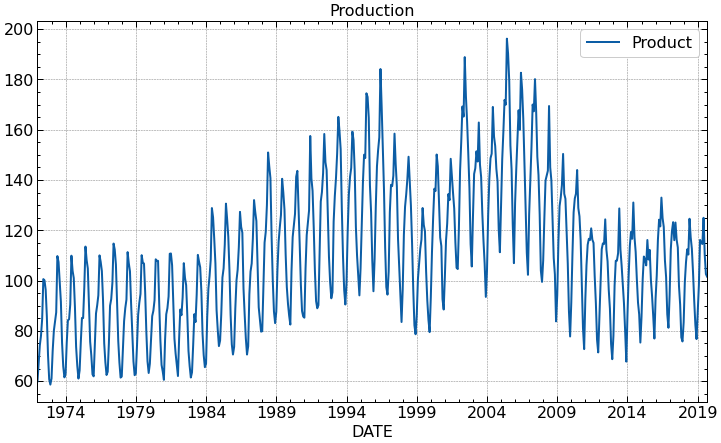

In [9]:
df.plot(figsize=(12, 7), title='Production');

## Train test split

- mengambil data testing selama 2 tahun atau 24 bulan

In [10]:
len(df)

573

In [11]:
test_point = 24

In [12]:
test_index = len(df)-test_point
test_index

549

In [13]:
train = df.iloc[:test_index]

In [14]:
test = df.iloc[test_index:]

In [15]:
train

,Product
DATE,
1972-01-01,59.9622
1972-02-01,67.0605
1972-03-01,74.2350
1972-04-01,78.1120
1972-05-01,84.7636
...,...
2017-05-01,116.0635
2017-06-01,123.0870
2017-07-01,116.2639


In [16]:
test

,Product
DATE,
2017-10-01,90.4732
2017-11-01,77.4378
2017-12-01,75.8118
2018-01-01,83.4343
2018-02-01,99.4899
2018-03-01,107.3152
2018-04-01,112.4309
2018-05-01,110.3544
2018-06-01,124.5841


In [17]:
train.shape, test.shape

((549, 1), (24, 1))

---
---
## Scaler data

In [18]:
from sklearn.preprocessing import MinMaxScaler

In [19]:
scaler = MinMaxScaler()

In [20]:
scaler_train = scaler.fit_transform(train)

In [21]:
scaler_test = scaler.transform(test)

----
----
## Timeseries Generator

In [22]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [23]:
help(TimeseriesGenerator)

Help on class TimeseriesGenerator in module keras.preprocessing.sequence:

class TimeseriesGenerator(keras.utils.data_utils.Sequence)
 |  TimeseriesGenerator(data, targets, length, sampling_rate=1, stride=1, start_index=0, end_index=None, shuffle=False, reverse=False, batch_size=128)
 |  
 |  Utility class for generating batches of temporal data.
 |  
 |  Deprecated: `tf.keras.preprocessing.sequence.TimeseriesGenerator` does not
 |  operate on tensors and is not recommended for new code. Prefer using a
 |  `tf.data.Dataset` which provides a more efficient and flexible mechanism for
 |  batching, shuffling, and windowing input. See the
 |  [tf.data guide](https://www.tensorflow.org/guide/data) for more details.
 |  
 |  This class takes in a sequence of data-points gathered at
 |  equal intervals, along with time series parameters such as
 |  stride, length of history, etc., to produce batches for
 |  training/validation.
 |  
 |  Arguments:
 |      data: Indexable generator (such as li

In [24]:
# # mendefiniskan 12 bulan sebelumya untuk mendapatkan prediksi bulan berikutnya
length = 12
generator = TimeseriesGenerator(scaler_train, scaler_train, length= length, batch_size=1)

In [25]:
# menampilkan batch pertama
X, y = generator[0]

In [26]:
print(f'Given the array : {X.flatten()} \n')
print(f'Predict y : {y}')

Given the array : [0.00947104 0.06108982 0.11326273 0.14145625 0.18982663 0.30495972
 0.30154406 0.27416065 0.19736841 0.08532665 0.01561588 0.        ] 

Predict y : [[0.01774221]]


---
----
## Create Model LSTM

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
import tensorflow as tf

In [28]:
tf.random.set_seed(7)

In [29]:
n_features = 1

In [30]:
model = Sequential()

# LSTM layers
model.add(LSTM(100, input_shape = (length, n_features), activation ='relu'))

# output layers
model.add(Dense(1))

# compile model
model.compile(loss='mse', optimizer='adam')

In [31]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 100)               40800     
                                                                 
 dense (Dense)               (None, 1)                 101       
                                                                 
Total params: 40,901
Trainable params: 40,901
Non-trainable params: 0
_________________________________________________________________


## Add Earlystopping and Validation Generator

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

In [33]:
ealy_stop = EarlyStopping(monitor='val_loss', patience=2)

In [34]:
# validation generator
validation_generator = TimeseriesGenerator(scaler_test, scaler_test, length=length, batch_size=1)

---
---
## Fitting Model Generator

In [35]:
model.fit(generator, epochs =20,
          validation_data = validation_generator, 
          callbacks =[ealy_stop]
         )

Epoch 1/20
537/537 [==============================] - 21s 25ms/step - loss: 0.0249 - val_loss: 0.0126
Epoch 2/20
537/537 [==============================] - 11s 21ms/step - loss: 0.0087 - val_loss: 0.0046
Epoch 3/20
537/537 [==============================] - 11s 20ms/step - loss: 0.0062 - val_loss: 0.0023
Epoch 4/20
537/537 [==============================] - 12s 22ms/step - loss: 0.0048 - val_loss: 0.0029
Epoch 5/20
537/537 [==============================] - 11s 21ms/step - loss: 0.0045 - val_loss: 0.0022
Epoch 6/20
537/537 [==============================] - 11s 21ms/step - loss: 0.0042 - val_loss: 0.0019
Epoch 7/20
537/537 [==============================] - 13s 23ms/step - loss: 0.0035 - val_loss: 0.0019
Epoch 8/20
537/537 [==============================] - 12s 22ms/step - loss: 0.0036 - val_loss: 0.0016
Epoch 9/20
537/537 [==============================] - 12s 23ms/step - loss: 0.0033 - val_loss: 0.0025
Epoch 10/20
537/537 [==============================] - 13s 25ms/step - loss: 0.003

In [36]:
losses = pd.DataFrame(model.history.history)

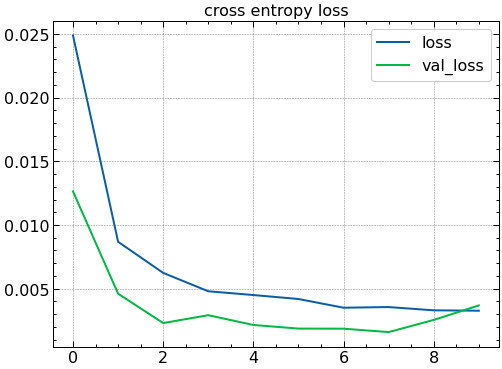

In [37]:
losses.plot(title='cross entropy loss');

------
## Evaluation on data test

In [38]:
test_prediction = []
first_evaluation_batch = scaler_train[-length:]
current_batch = first_evaluation_batch.reshape((1, length, n_features))

for i in range(len(test)):
    # predict current
    current_pred  = model.predict(current_batch)[0]
    # store predict
    test_prediction.append(current_pred)
    
    # update batch | predict | drop first values
    current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis=1)

1/1 [==============================] - 0s 67ms/step


---------
-----
## Inverse transform and compire

In [39]:
true_prediction = scaler.inverse_transform(test_prediction)

In [40]:
true_prediction

array([[ 99.18017062],
       [ 96.67067057],
       [100.21747862],
       [110.52342136],
       [121.84423836],
       [130.9500011 ],
       [136.63363634],
       [138.57440403],
       [137.70448838],
       [132.00736995],
       [123.22010144],
       [112.9900334 ],
       [107.33933976],
       [107.22419989],
       [113.56694174],
       [123.87404018],
       [135.07578301],
       [145.00984383],
       [152.04190447],
       [154.86322683],
       [152.74098116],
       [145.61251367],
       [134.84362627],
       [123.5336368 ]])

In [41]:
test['Prediction'] = true_prediction

C:\Users\ibrahim\AppData\Local\Temp\ipykernel_1776\249045001.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Prediction'] = true_prediction


In [42]:
test

,Product,Prediction
DATE,,
2017-10-01,90.4732,99.180171
2017-11-01,77.4378,96.670671
2017-12-01,75.8118,100.217479
2018-01-01,83.4343,110.523421
2018-02-01,99.4899,121.844238
2018-03-01,107.3152,130.950001
2018-04-01,112.4309,136.633636
2018-05-01,110.3544,138.574404
2018-06-01,124.5841,137.704488


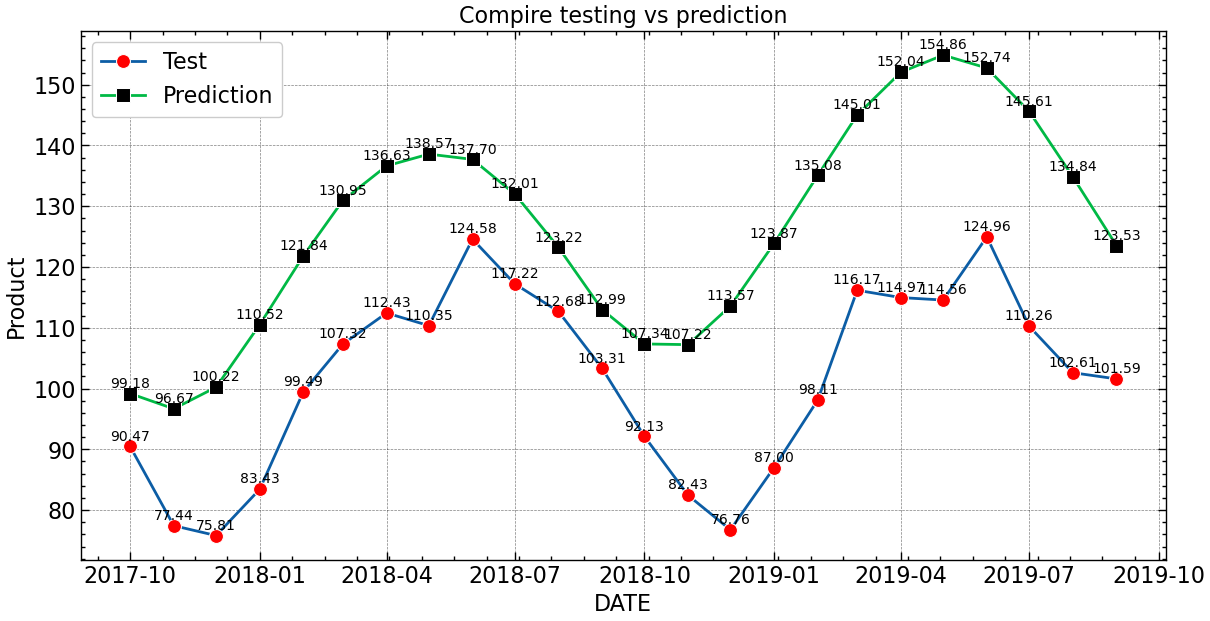

In [43]:
plt.figure(figsize=(14, 7), dpi=100)
sns.lineplot(x=test.index, y='Product', data=test, marker='o', markersize=10, markerfacecolor='red', label='Test')

for x,y in zip(test.index, test['Product']):
    plt.text(x=x,
             y = y + 1, 
             s ='{:.2f}'.format(y),
             ha ='center')
    
sns.lineplot(x=test.index, y='Prediction', data=test, marker='s', markersize=10, markerfacecolor='yellow', label='Prediction')

for x,y in zip(test.index, test['Prediction']):
    plt.text(x=x,
             y = y + 1, 
             s ='{:.2f}'.format(y),
             ha ='center')
plt.title('Compire testing vs prediction')
plt.show()

-----
## Retrain and forease full data

In [44]:
# scaler
scaler_full = MinMaxScaler()

In [45]:
scaler_full_data = scaler_full.fit_transform(df)

In [46]:
# generator
length = 12
generator = TimeseriesGenerator(scaler_full_data, scaler_full_data, length=length, batch_size=1)

In [47]:
# model
model = Sequential()

model.add(LSTM(100, input_shape=(length, n_features), activation='relu'))
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam')

In [48]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, 100)               40800     
                                                                 
 dense_1 (Dense)             (None, 1)                 101       
                                                                 
Total params: 40,901
Trainable params: 40,901
Non-trainable params: 0
_________________________________________________________________


In [49]:
model.fit(generator, epochs=8, verbose=1)

Epoch 1/8
561/561 [==============================] - 18s 21ms/step - loss: 0.0246
Epoch 2/8
561/561 [==============================] - 13s 22ms/step - loss: 0.0091
Epoch 3/8
561/561 [==============================] - 13s 23ms/step - loss: 0.0059
Epoch 4/8
561/561 [==============================] - 13s 23ms/step - loss: 0.0050
Epoch 5/8
561/561 [==============================] - 12s 21ms/step - loss: 0.0042
Epoch 6/8
561/561 [==============================] - 13s 22ms/step - loss: 0.0045
Epoch 7/8
561/561 [==============================] - 13s 24ms/step - loss: 0.0046
Epoch 8/8
561/561 [==============================] - 13s 23ms/step - loss: 0.0039


In [50]:
losses = pd.DataFrame(model.history.history)

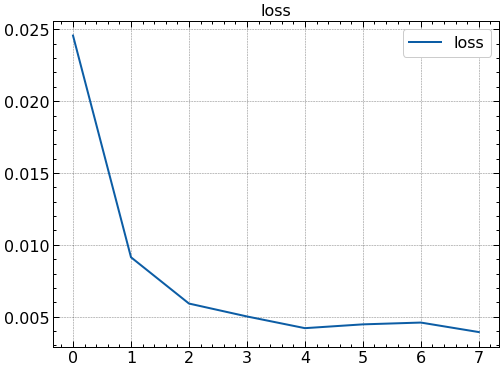

In [51]:
losses.plot(title='loss');

In [52]:
# evaluation on test data

forecase =[]

periods = 12
first_evaluation_batch = scaler_full_data[-length:]
current_batch = first_evaluation_batch.reshape((1, length, n_features))

for i in range(periods):
    # current pred
    current_pred = model.predict(current_batch)[0]
    # store predict
    forecase.append(current_pred)
    # update batch | prediction |  drop first value
    current_batch = np.append(current_batch[:, 1:, :], [[current_pred]], axis=1)

1/1 [==============================] - 0s 86ms/step


In [53]:
forecase = scaler.inverse_transform(forecase)

In [54]:
forecase

array([[ 91.13514958],
       [ 82.15880087],
       [ 81.5399594 ],
       [ 90.99794072],
       [104.48864127],
       [115.31794892],
       [121.00460046],
       [126.80994914],
       [127.08342427],
       [119.44856674],
       [112.45071406],
       [104.04985569]])

## Create new stamtamp index

In [55]:
df

,Product
DATE,
1972-01-01,59.9622
1972-02-01,67.0605
1972-03-01,74.2350
1972-04-01,78.1120
1972-05-01,84.7636
...,...
2019-05-01,114.5613
2019-06-01,124.9605
2019-07-01,110.2632


In [56]:
df.tail()

,Product
DATE,
2019-05-01,114.5613
2019-06-01,124.9605
2019-07-01,110.2632
2019-08-01,102.6085
2019-09-01,101.5866


## Pandas frequency string

https://stackoverflow.com/questions/35339139/where-is-the-documentation-on-pandas-freq-tags

https://pandas.pydata.org/docs/user_guide/timeseries.html

`MS` month start frequency

In [57]:
forecase_index = pd.date_range(start='2019-11-01', periods =periods, freq='MS')

In [58]:
forecase_index

DatetimeIndex(['2019-11-01', '2019-12-01', '2020-01-01', '2020-02-01',
               '2020-03-01', '2020-04-01', '2020-05-01', '2020-06-01',
               '2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01'],
              dtype='datetime64[ns]', freq='MS')

In [59]:
forecase_df = pd.DataFrame(data=forecase, index=forecase_index, columns=['forecase'])

In [60]:
forecase_df

,forecase
2019-11-01,91.135150
2019-12-01,82.158801
2020-01-01,81.539959
2020-02-01,90.997941
2020-03-01,104.488641
2020-04-01,115.317949
2020-05-01,121.004600
2020-06-01,126.809949
2020-07-01,127.083424
2020-08-01,119.448567


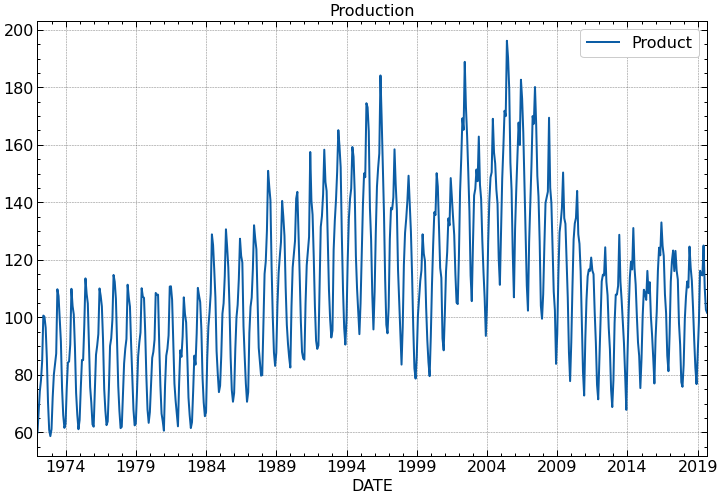

In [61]:
df.plot(figsize=(12, 8), title=('Production'));

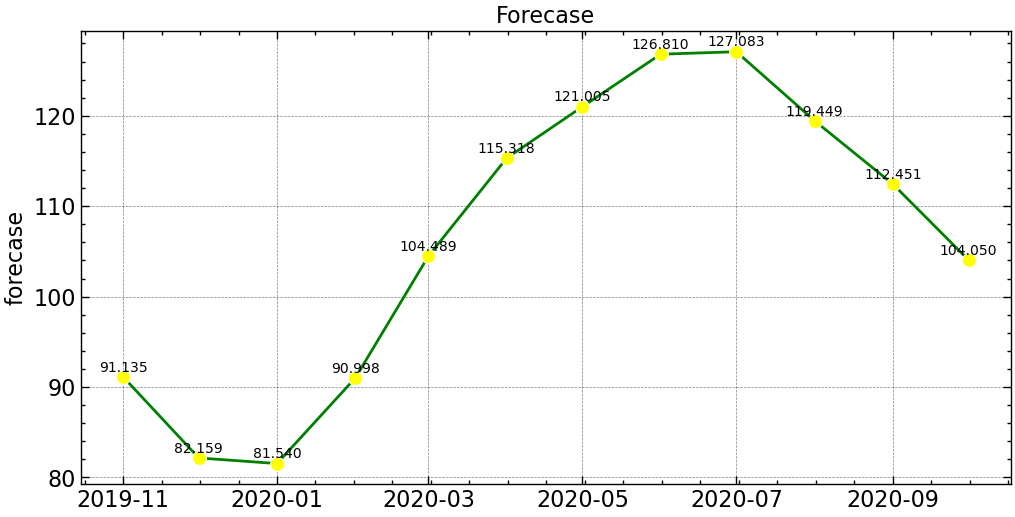

In [62]:
plt.figure(figsize=(12, 6), dpi=100)
sns.lineplot(x=forecase_index, y='forecase', data=forecase_df, marker='o', markerfacecolor='yellow', markersize=10,  color='green' )

for x,y in zip(forecase_index, forecase_df['forecase']):
    plt.text(x= x,
             y= y+0.6 ,
             s='{:.3f}'.format(y),
             ha='center')
plt.title('Forecase') ;

## Join plot

Text(0.5, 1.0, 'Production vs forecase')

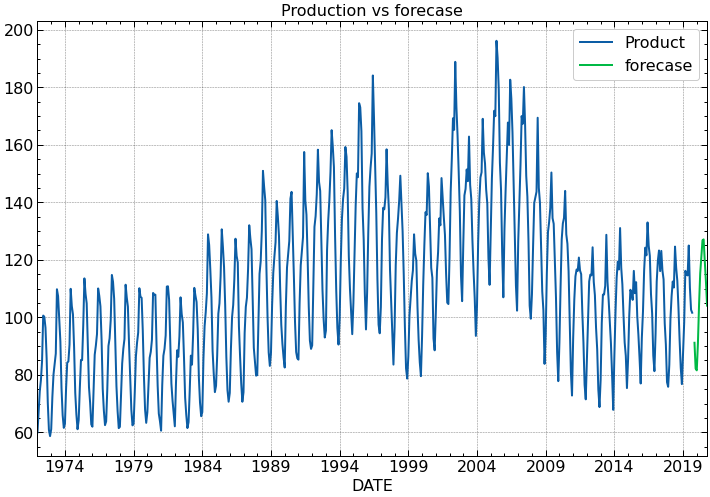

In [63]:
ax = df.plot(figsize=(12, 8))
forecase_df.plot(ax=ax);
plt.title('Production vs forecase')

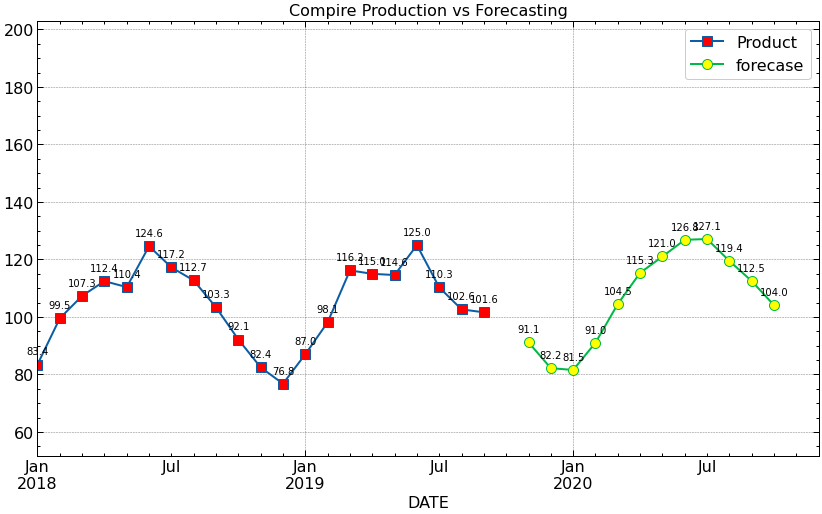

In [64]:
ax = df.plot(figsize=(14, 8), marker='s', markerfacecolor='red', markersize=10)
forecase_df.plot(ax=ax, marker='o', markerfacecolor='yellow', markersize=10);
plt.xlim('2018-01-01', '2020-12-01')

for x,y in zip(df.index, df['Product']):
    label = "{:.1f}".format(y)

    plt.annotate(label, # this is the text
                 (x,y), # these are the coordinates to position the label
                 textcoords="offset points", # how to position the text
                 xytext=(0,10), # distance from text to points (x,y)
                 ha='center') 
    
for x,y in zip(forecase_df.index, forecase_df['forecase']):
    label = "{:.1f}".format(y)

    plt.annotate(label, # this is the text
                 (x,y), # these are the coordinates to position the label
                 textcoords="offset points", # how to position the text
                 xytext=(0,10), # distance from text to points (x,y)
                 ha='center') 
plt.title('Compire Production vs Forecasting');